In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
# Seed zapewnia identyczne dane u każdego studenta
np.random.seed(42)
n = 200
dzialy = np.random.choice(['IT', 'Sprzedaz', 'HR', 'Marketing', 'Finanse'], n,
 p=[0.30, 0.25, 0.15, 0.20, 0.10])
staz = np.random.gamma(shape=3, scale=2, size=n).clip(0.5, 20).round(1)
baza = {'IT': 9000, 'Sprzedaz': 7000, 'HR': 6500, 'Marketing': 7500, 'Finanse':
8500}
wynagrodzenie = np.array([
 baza[d] + staz[i] * 300 + np.random.normal(0, 1200)
 for i, d in enumerate(dzialy)
]).clip(4000, 25000).round(-2)
# 5 celowo wstawionych outlierów (błędy danych / kontrakty specjalne)
wynagrodzenie[np.random.choice(n, 5, replace=False)] = np.random.choice(
 [2000, 2500, 35000, 40000, 38000], 5, replace=False
)

df = pd.DataFrame({
 'dzial': dzialy,
 'staz_lat': staz,
 'wynagrodzenie': wynagrodzenie,
 'wiek': (25 + staz + np.random.normal(0, 3, n)).clip(22,
65).round().astype(int),
 'ocena_roczna': np.random.choice([1, 2, 3, 4, 5], n, p=[0.05, 0.10, 0.40,
0.35, 0.10])
})
print(f"Dataset HR: {df.shape[0]} pracowników, {df.shape[1]} kolumn")
print(df.head())
print("\nTypy kolumn:")
print(df.dtypes)


Dataset HR: 200 pracowników, 5 kolumn
       dzial  staz_lat  wynagrodzenie  wiek  ocena_roczna
0   Sprzedaz       3.4         9100.0    27             5
1    Finanse       6.1        12600.0    35             3
2  Marketing       6.3         7700.0    38             3
3         HR       3.3         8200.0    27             4
4         IT      14.0        12400.0    38             4

Typy kolumn:
dzial                str
staz_lat         float64
wynagrodzenie    float64
wiek               int64
ocena_roczna       int64
dtype: object


## Ćwiczenie 1: Statystyki opisowe na danych biznesowych 

In [ ]:
placa = df['wynagrodzenie']

srednia = placa.mean()
mediana = placa.median()
dominanta = placa.mode().iloc[0]

print("=== MIARY TENDENCJI CENTRALNEJ ===")
print(f"Średnia: {srednia:>10,.0f} PLN")
print(f"Mediana: {mediana:>10,.0f} PLN")
print(f"Dominanta: {dominanta:>10,.0f} PLN")

# Odpowiedź:
# Tak, mediana < średnia.
# Oznacza to, że rozkład jest prawostronnie skośny.
# Średnią zawyżają nieliczni pracownicy z bardzo wysokimi wynagrodzeniami

=== MIARY TENDENCJI CENTRALNEJ ===
Średnia:      9,940 PLN
Mediana:      9,450 PLN
Dominanta:      9,500 PLN


In [ ]:
odch_std = placa.std()
q1 = placa.quantile(0.25)
q3 = placa.quantile(0.75)
iqr = q3 - q1
rozstep = placa.max() - placa.min()

print("=== MIARY ROZPROSZENIA ===")
print(f"Odchylenie std: {odch_std:>10,.0f} PLN")
print(f"Q1 (P25): {q1:>10,.0f} PLN")
print(f"Q3 (P75): {q3:>10,.0f} PLN")
print(f"IQR: {iqr:>10,.0f} PLN")
print(f"Rozstęp: {rozstep:>10,.0f} PLN")

# Odpowiedź:
# Rozstęp jest bardzo duży, ponieważ w danych znajdują się wartości odstające.
# Minimalne wynagrodzenia wynoszą około 2000 PLN,
# a maksymalne około 40000 PLN.
# Rozstęp uwzględnia tylko minimum i maksimum, więc silnie reaguje na outliery.

=== MIARY ROZPROSZENIA ===
Odchylenie std:      3,980 PLN
Q1 (P25):      8,200 PLN
Q3 (P75):     10,700 PLN
IQR:      2,500 PLN
Rozstęp:     38,000 PLN


In [10]:
dzialy_stats = df.groupby('dzial', observed=True)['wynagrodzenie'].agg([
    'mean', 'median', 'std'
]).round(0).sort_values('median', ascending=False)

dzialy_stats.columns = ['Średnia', 'Mediana', 'Std']

print("=== WYNAGRODZENIA PER DZIAŁ ===")
print(dzialy_stats)

=== WYNAGRODZENIA PER DZIAŁ ===
           Średnia  Mediana     Std
dzial                              
IT         11108.0  10600.0  4145.0
Finanse    10621.0  10400.0  1741.0
Marketing   9476.0   9100.0  4386.0
HR          8354.0   8400.0  1622.0
Sprzedaz    9282.0   8400.0  4428.0


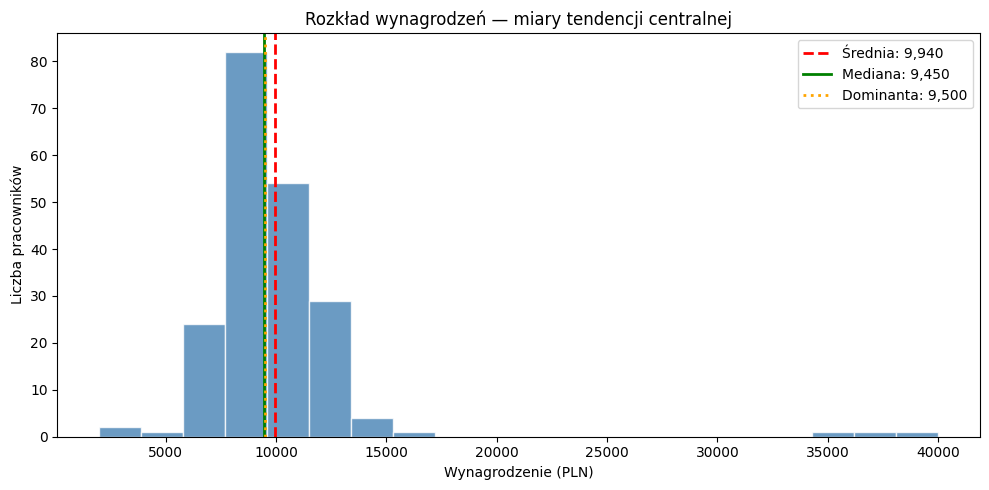

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(placa, bins=20, color='steelblue', alpha=0.8, edgecolor='white')

ax.axvline(srednia, color='red', linestyle='--', lw=2,
           label=f'Średnia: {srednia:,.0f}')

ax.axvline(mediana, color='green', linestyle='-', lw=2,
           label=f'Mediana: {mediana:,.0f}')

ax.axvline(dominanta, color='orange', linestyle=':', lw=2,
           label=f'Dominanta: {dominanta:,.0f}')

ax.set_title('Rozkład wynagrodzeń — miary tendencji centralnej')
ax.set_xlabel('Wynagrodzenie (PLN)')
ax.set_ylabel('Liczba pracowników')
ax.legend()

plt.tight_layout()
plt.show()
plt.close()

## Ćwiczenie 2: Analiza korelacji

In [11]:
r, p_value = stats.pearsonr(df['staz_lat'], df['wynagrodzenie'])

print(f"Korelacja Pearsona (staż–wynagrodzenie):")
print(f" r = {r:.4f}")
print(f" p = {p_value:.4f}")
print(f" Interpretacja: {'istotna' if p_value < 0.05 else 'nieistotna'} statystycznie")

Korelacja Pearsona (staż–wynagrodzenie):
 r = 0.3198
 p = 0.0000
 Interpretacja: istotna statystycznie


In [ ]:
# Oblicz korelację Spearmana (odporniejsza na outliery)

rho, p_rho = stats.spearmanr(df['staz_lat'], df['wynagrodzenie'])

print(f"Korelacja Spearmana (staż–wynagrodzenie):")
print(f" rho = {rho:.4f}")
print(f" p = {p_rho:.4f}")

print(f"\nPorównanie: Pearson r={r:.3f} vs Spearman rho={rho:.3f}")
print(f"Różnica: {abs(rho - r):.3f} — {'duże' if abs(rho-r) > 0.1 else 'małe'} rozbieżności")

# Odpowiedź:
# Spearman jest wyższy od Pearsona, ponieważ wykorzystuje rangi, a nie rzeczywiste wartości.
# Dzięki temu jest bardziej odporny na wartości odstające (outliery), które obniżają korelację Pearsona.

Korelacja Spearmana (staż–wynagrodzenie):
 rho = 0.5219
 p = 0.0000

Porównanie: Pearson r=0.320 vs Spearman rho=0.522
Różnica: 0.202 — duże rozbieżności


Macierz korelacji Pearsona:
               staz_lat  wynagrodzenie   wiek  ocena_roczna
staz_lat          1.000          0.320  0.756        -0.057
wynagrodzenie     0.320          1.000  0.219        -0.054
wiek              0.756          0.219  1.000        -0.081
ocena_roczna     -0.057         -0.054 -0.081         1.000


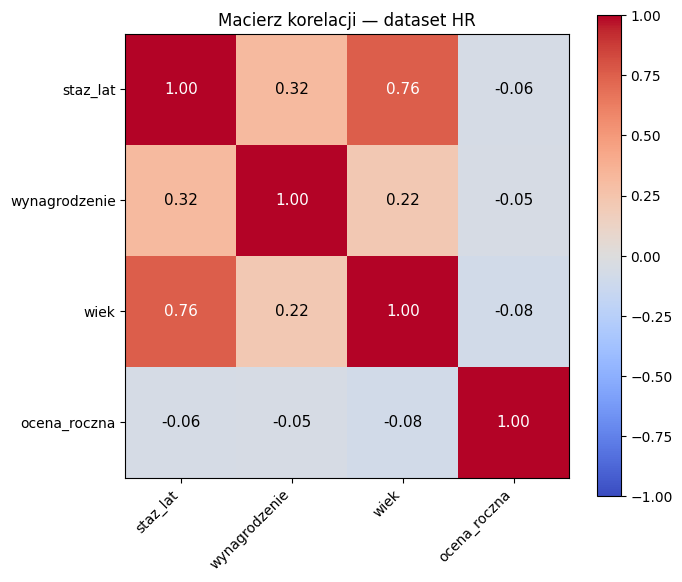

In [18]:
# Oblicz pełną macierz korelacji Pearsona
corr = df[['staz_lat', 'wynagrodzenie', 'wiek', 'ocena_roczna']].corr()

print("Macierz korelacji Pearsona:")
print(corr.round(3))

# Wizualizacja — heatmapa (matplotlib już zaimportowany w Setupie)
fig, ax = plt.subplots(figsize=(7, 6))

# Rysuj heatmapę ręcznie (bez seaborn)
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))

ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)

# Dodaj wartości w komórkach
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(
            j, i,
            f'{corr.values[i, j]:.2f}',
            ha='center',
            va='center',
            fontsize=11,
            color='black' if abs(corr.values[i, j]) < 0.7 else 'white'
        )

ax.set_title('Macierz korelacji — dataset HR')
plt.tight_layout()
plt.show()
plt.close()

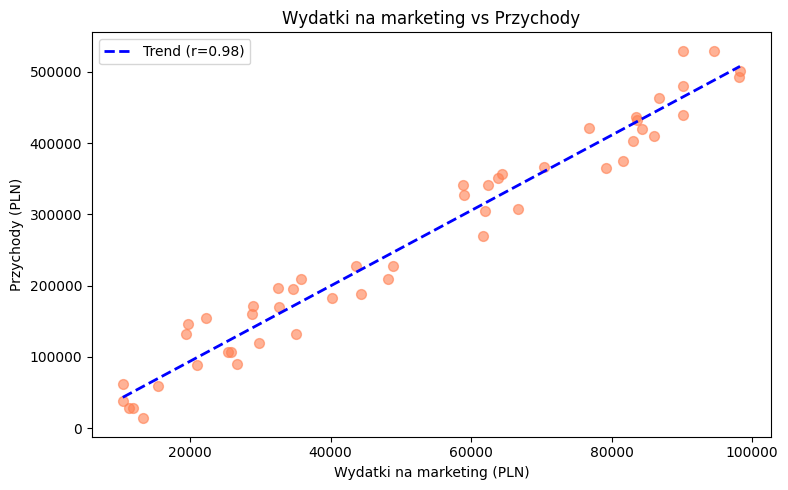

Marketing spend vs Revenue: r = 0.9806, p = 1.22e-35


In [16]:
np.random.seed(100)
n_mkt = 50
marketing_spend = np.random.uniform(10000, 100000, n_mkt)
revenue = marketing_spend * 5.2 + np.random.normal(0, 30000, n_mkt)
revenue = revenue.clip(0)
# Oblicz korelację Pearsona
r_mkt, p_mkt = stats.pearsonr(marketing_spend, revenue)
# Scatter plot z linią trendu
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(marketing_spend, revenue, alpha=0.6, color='coral', s=50)
# Dodaj linię trendu (polyfit stopień 1)
z = np.polyfit(marketing_spend, revenue, 1)
p_fit = np.poly1d(z)
x_line = np.linspace(marketing_spend.min(), marketing_spend.max(), 100)
ax.plot(x_line, p_fit(x_line), 'b--', lw=2, label=f'Trend (r={r_mkt:.2f})')
ax.set_title('Wydatki na marketing vs Przychody')
ax.set_xlabel('Wydatki na marketing (PLN)')
ax.set_ylabel('Przychody (PLN)')
ax.legend()
plt.tight_layout()
plt.show()
plt.close()
print(f"Marketing spend vs Revenue: r = {r_mkt:.4f}, p = {p_mkt:.2e}")

## Ćwiczenie 3: Pełna analiza statystyczna datasetu HR

In [19]:
opis = stats.describe(df['wynagrodzenie'])

print("=== DESCRIBE ===")
print(f"n: {opis.nobs}")
print(f"min: {opis.minmax[0]:.0f}")
print(f"max: {opis.minmax[1]:.0f}")
print(f"mean: {opis.mean:.0f}")
print(f"variance: {opis.variance:.0f}")
print(f"skewness: {opis.skewness:.3f}")
print(f"kurtosis: {opis.kurtosis:.3f}")

# Interpretacja:
# Skośność >> 1 oznacza silnie prawostronny rozkład.
# Kurtoza bardzo wysoka oznacza ciężkie ogony i dużo outlierów.

=== DESCRIBE ===
n: 200
min: 2000
max: 40000
mean: 9940
variance: 15838191
skewness: 5.102
kurtosis: 34.159


In [20]:
percentyle = np.percentile(df['wynagrodzenie'], [10, 25, 50, 75, 90, 95, 99])

labels = ["P10", "P25", "P50", "P75", "P90", "P95", "P99"]

print("=== PERCENTYLE ===")
for l, v in zip(labels, percentyle):
    print(f"{l}: {v:,.0f} PLN")

# Pytania biznesowe:

p75 = np.percentile(df['wynagrodzenie'], 75)
powyzej_12k = (df['wynagrodzenie'] > 12000).mean() * 100

print("\n=== WNIOSKI ===")
print(f"P75 = {p75:,.0f} PLN")
print(f"% > 12 000 PLN = {powyzej_12k:.1f}%")

# Interpretacja:
# P75 oznacza próg, powyżej którego znajduje się 25% najlepiej zarabiających.
# Około 10–13% pracowników zarabia powyżej 12 000 PLN.

=== PERCENTYLE ===
P10: 7,190 PLN
P25: 8,200 PLN
P50: 9,450 PLN
P75: 10,700 PLN
P90: 12,310 PLN
P95: 13,105 PLN
P99: 35,030 PLN

=== WNIOSKI ===
P75 = 10,700 PLN
% > 12 000 PLN = 13.0%


In [21]:
dzial_stats = df.groupby('dzial', observed=True)['wynagrodzenie'].agg([
    'mean',
    'median',
    'std',
    'min',
    'max',
    lambda x: x.quantile(0.75) - x.quantile(0.25)
])

dzial_stats.columns = ['Średnia', 'Mediana', 'Std', 'Min', 'Max', 'IQR']
dzial_stats = dzial_stats.sort_values('Mediana', ascending=False)

print("=== STATYSTYKI PER DZIAŁ ===")
print(dzial_stats)

# Interpretacja:
# IT ma najwyższe wynagrodzenia i największą zmienność.
# HR i Sprzedaż mają niższe mediany i bardziej stabilne rozkłady.

=== STATYSTYKI PER DZIAŁ ===
                Średnia  Mediana          Std     Min      Max     IQR
dzial                                                                 
IT         11107.575758  10600.0  4144.813649  2500.0  40000.0  2750.0
Finanse    10621.052632  10400.0  1741.193380  8300.0  16200.0  2000.0
Marketing   9475.609756   9100.0  4386.386924  2000.0  35000.0  1500.0
HR          8354.166667   8400.0  1622.123988  4500.0  10800.0  2425.0
Sprzedaz    9282.000000   8400.0  4428.096288  5900.0  38000.0  2075.0


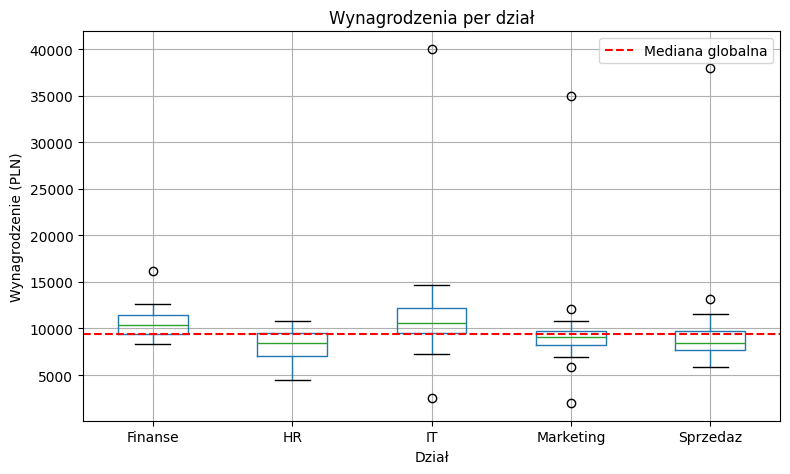

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))

df.boxplot(column='wynagrodzenie', by='dzial', ax=ax)

ax.axhline(
    df['wynagrodzenie'].median(),
    color='red',
    linestyle='--',
    label='Mediana globalna'
)

ax.set_title("Wynagrodzenia per dział")
ax.set_xlabel("Dział")
ax.set_ylabel("Wynagrodzenie (PLN)")
ax.legend()

plt.suptitle("")  # usuwa domyślny tytuł pandas
plt.tight_layout()
plt.show()

In [23]:
for d in ['IT', 'HR']:
    podzb = df[df['dzial'] == d]['wynagrodzenie']
    opis = stats.describe(podzb)

    print(f"\n{d} (n={opis.nobs}):")
    print(f" Skośność: {opis.skewness:.3f}")
    print(f" Kurtoza: {opis.kurtosis:.3f}")

    # Interpretacja:
    # IT: silnie prawoskośny rozkład → wysokie outliery (premie, seniorzy)
    # HR: bardziej symetryczny → brak ekstremalnych wartości


IT (n=66):
 Skośność: 5.067
 Kurtoza: 34.256

HR (n=24):
 Skośność: -0.460
 Kurtoza: -0.404


## Ćwiczenie 4: Wykrywanie outlierów + commit

In [ ]:
# Oblicz granice IQR
q1 = df['wynagrodzenie'].quantile(0.25)
q3 = df['wynagrodzenie'].quantile(0.75)
iqr = q3 - q1

dolna = q1 - 1.5 * iqr
gorna = q3 + 1.5 * iqr

print(f"IQR granice: [{dolna:,.0f} PLN, {gorna:,.0f} PLN]")

# Wykrywanie outlierów
maska_iqr = (df['wynagrodzenie'] < dolna) | (df['wynagrodzenie'] > gorna)
outliery = df[maska_iqr]

print(f"Liczba outlierów: {maska_iqr.sum()} z {len(df)}")

print("\nSzczegóły outlierów:")
print(outliery[['dzial', 'staz_lat', 'wynagrodzenie']].to_string())


IQR granice: [4,450 PLN, 14,450 PLN]
Liczba outlierów: 7 z 200

Szczegóły outlierów:
         dzial  staz_lat  wynagrodzenie
51   Marketing       3.1         2000.0
61          IT      10.6        14700.0
79          IT       6.3        40000.0
83          IT       8.8         2500.0
138   Sprzedaz      13.8        38000.0
154    Finanse      15.3        16200.0
183  Marketing       3.7        35000.0


In [ ]:
# Oblicz z-score (wartości bezwzględne)
z_scores = np.abs(stats.zscore(df['wynagrodzenie']))

maska_z = z_scores > 3.0
outliery_z = df[maska_z]

print(f"Outlierzy z-score (|z| > 3.0): {maska_z.sum()} obserwacji")

print(outliery_z[['dzial', 'staz_lat', 'wynagrodzenie']].to_string())


Outlierzy z-score (|z| > 3.0): 3 obserwacji
         dzial  staz_lat  wynagrodzenie
79          IT       6.3        40000.0
138   Sprzedaz      13.8        38000.0
183  Marketing       3.7        35000.0


In [ ]:
bez_outlierow = df[~maska_iqr]['wynagrodzenie']
z_outlierami = df['wynagrodzenie']

print(f"{'Miara':<20} {'Z outlierami':>15} {'Bez outlierów':>15} {'Zmiana':>12}")
print("-" * 65)

for nazwa, f_z, f_bez in [
    ('Średnia', z_outlierami.mean(), bez_outlierow.mean()),
    ('Mediana', z_outlierami.median(), bez_outlierow.median()),
    ('Std', z_outlierami.std(), bez_outlierow.std()),
]:
    zmiana = f_z - f_bez
    print(f"{nazwa:<20} {f_z:>15,.0f} {f_bez:>15,.0f} {zmiana:>+12,.0f}")

# Najbardziej stabilną miarą jest mediana.
# Dlaczego?
# - nie zmienia się istotnie po usunięciu outlierów
# - opisuje środek rozkładu niezależnie od ekstremów

Miara                   Z outlierami   Bez outlierów       Zmiana
-----------------------------------------------------------------
Średnia                        9,940           9,532         +408
Mediana                        9,450           9,400          +50
Std                            3,980           1,798       +2,182
